## Project 1

The goal of the first project is to do some wrangling, EDA, and visualization, and generate sequences of values. We will focus on:

- CDC National Health and Nutritional Examination Survey (NHANES, 1999-2000): https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=1999
- CDC Linked Mortality File (LMF, 1999-2000): https://www.cdc.gov/nchs/data-linkage/mortality-public.htm

NHANES is a rich panel dataset on health and behavior, collected bi-yearly from around 1999 to now. We will focus on the 1999 wave, because that has the largest follow-up window, providing us with the richest mortality data. The mortality data is provided by the CDC Linked Mortality File.

The purpose of the project is to use $k$-NN to predict who dies (hard or soft classification) and how long they live (regression).

### Part 1: Wrangling and EDA (40/100 pts)

First, go to the NHANES and LMF web sites and familiarize yourself with the data sources. Download codebooks. Think about what resources are available. The CDC Linked Mortality File is somewhat of a pain to work with, so I have pre-cleaned it for you. It is available at httts://github.com/ds4e/undergraduate_ml_assignments in the data folder, as `lmf_parsed.cav`. From the CDC LMF web page, get the SAS program to load the data; it is the real codebook.

Second, download the demographic data for the 1999--2000 wave from the NHANES page. You can use the following code chunk to merge the LMF and DEMO data:

``` python
import pandas as pd
mdf = pd.read_csv('linked_mortality_file_1999_2000.csv') # Load mortality file
print( mdf.head() )
gdf = pd.read_sas("DEMO.xpt", format="xport") # Load demographics file
print( gdf.head() )
df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable
```

Third, the variables `ELIGSTAT`, `MORTSTAT`, `PERMTH_INT`, and `RIDAGEEX` are particularly important. Look them up in the documentation and clearly describe them. (5/100 pts.)

Second, the goal of the project is to use whatever demographic, behavioral, and health data you like to predict mortality (`MORTSTAT`) and life expectancy (`PERMTH_INT`). Go to the NHANES 1999--2000 web page and select your data and download it. Clearly explain your rationale for selecting these data. Use `.merge` to combine your data into one complete dataframe. Document missing values. (5/100 pts)

Third, do basic EDA and visualization of the key variables. Are any important variables skewed? Are there outliers? How correlated are pairs of variables? Do pairs of categorical variables exhibit interesting patterns in contingency tables? Provide a clear discussion and examination of the data and the variables you are interested in using. (20/100 pts)


### Part 2: $k$-NN classification/regression, write-up (50/100 pts)

Submit a notebook that clearly addresses the following, using code and markdown chunks:

1. Describe the data, particularly what an observation is and whether there are any missing data that might impact your analysis. Who collected the data and why? What known limitations are there to analysis? (10/100 pts)
2. Describe the variables you selected to predict mortality and life expectancy, and the rationale behind them. Analyze your variables using describe tables, kernel densities, scatter plots, and conditional kernel densities. Are there any patterns of interest to notice? (10/100 pts)
3. Using your variables to predict mortality using a $k$-Nearest Neighbor Classifier. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
4. Using your variables to predict life expectancy using a $k$-Nearest Neighbor Regressor. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
5. Describe how your model could be used for health interventions based on patient characteristics. Are there any limitations or risks to consider? (10/100 pts)

## Submission (10/100 pts)

Submit your work in a well-organized GitHub repo, where the code is appropriately commented and all members of the group have made significant contributions to the commit history. (10/100 pts)

In [3]:
import pandas as pd
mdf = pd.read_csv('data/linked_mortality_file_1999_2000.csv') # Load mortality file
print( mdf.head() )
gdf = pd.read_sas("data/DEMO.xpt", format="xport") # Load demographics file
print( gdf.head() )
df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable

   SEQN  ELIGSTAT  MORTSTAT  UCOD_LEADING  DIABETES  HYPERTEN  PERMTH_INT  \
0     1         2       NaN           NaN       NaN       NaN         NaN   
1     2         1       1.0           6.0       0.0       0.0       177.0   
2     3         2       NaN           NaN       NaN       NaN         NaN   
3     4         2       NaN           NaN       NaN       NaN         NaN   
4     5         1       0.0           NaN       NaN       NaN       244.0   

   PERMTH_EXM  
0         NaN  
1       177.0  
2         NaN  
3         NaN  
4       244.0  
   SEQN  SDDSRVYR  RIDSTATR  RIDEXMON  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDAGEEX  \
0   1.0       1.0       2.0       2.0       2.0       2.0      29.0      31.0   
1   2.0       1.0       2.0       2.0       1.0      77.0     926.0     926.0   
2   3.0       1.0       2.0       1.0       2.0      10.0     125.0     126.0   
3   4.0       1.0       2.0       2.0       1.0       1.0      22.0      23.0   
4   5.0       1.0       2.0       2.

In [4]:
df[["ELIGSTAT", "MORTSTAT", "PERMTH_INT", "RIDAGEEX"]].head()

,ELIGSTAT,MORTSTAT,PERMTH_INT,RIDAGEEX
0,2,NaN,NaN,31.0
1,1,1.0,177.0,926.0
2,2,NaN,NaN,126.0
3,2,NaN,NaN,23.0
4,1,0.0,244.0,597.0


ELIGSTAT (Eligibility Status for Mortality Linkage)

This variable indicates whether a NHANES participant could be successfully linked to the National Death Index (NDI) to determine mortality outcomes. Only participants with sufficient identifying information are eligible. If a participant is not eligible, their mortality status cannot be determined.

MORTSTAT (Mortality Status)

This variable shows the participant’s vital status at the end of the follow-up period based on NDI linkage. A value of 1 indicates the participant is assumed deceased, while 0 indicates the participant is assumed alive. This variable is only available for participants who are eligible for mortality linkage.

PERMTH_INT (Person-Months of Follow-Up from Interview)

This variable measures the total number of months a participant was followed starting from their NHANES interview date until either the date of death or the end of the follow-up period. It represents the amount of time each participant contributes to survival or mortality analysis.

RIDAGEEX (Age in Months at Examination)

This variable records the participant’s age in months at the time of their NHANES medical examination (MEC). Using age in months provides a more precise measure than age in years, which is especially important for younger participants and age-sensitive analyses.

We chose to download BPX (blood pressure) as it is a good predictor of cardiovascular disease and stroke, which are all common causes of mortality. Hypertension is strongly associated with increased mortality risk, making blood pressure measurements highly relevant for predicting both MORTSTAT and PERMTH_INT. Unlike self-reported data, BPX provides objective health measurements, improving predictive reliability.

In [ ]:
bpx_df = pd.read_sas("./data/BPX.xpt", format="xport")  # exam blood pressure
bpq_df = pd.read_sas("./data/BPQ.xpt", format="xport")  # questionnaire
smq_df = pd.read_sas("./data/SMQ.xpt", format="xport")  # smoking questionnaire

print(bpx_df.head())
print(bpq_df.head())
print(smq_df.head())

# Merging into main dataframe
df = df.merge(bpx_df, on="SEQN", how="left")
df = df.merge(bpq_df, on="SEQN", how="left")
df = df.merge(smq_df, on="SEQN", how="left")

print(df.shape)
print(df[["SEQN","ELIGSTAT","MORTSTAT","PERMTH_INT","RIDAGEEX"]].head())

   SEQN  PEASCST1  PEASCTM1      PEASCCT1  BPXCHR  BPQ150A  BPQ150B  BPQ150C  \
0   1.0       1.0     151.0  5.397605e-79   110.0      NaN      NaN      NaN   
1   2.0       1.0     764.0  5.397605e-79     NaN      2.0      2.0      2.0   
2   3.0       1.0     571.0  5.397605e-79     NaN      2.0      2.0      2.0   
3   4.0       1.0      47.0  5.397605e-79   108.0      NaN      NaN      NaN   
4   5.0       1.0     694.0  5.397605e-79     NaN      2.0      2.0      2.0   

   BPQ150D  BPAARM  ...  BPXDI2  BPAEN2  BPXSY3  BPXDI3  BPAEN3  BPXSY4  \
0      NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
1      2.0     1.0  ...    56.0     2.0    98.0    56.0     2.0     NaN   
2      2.0     1.0  ...    64.0     2.0   112.0    62.0     2.0     NaN   
3      NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
4      2.0     1.0  ...    84.0     2.0   122.0    82.0     2.0     NaN   

   BPXDI4  BPAEN4  BPXSAR  BPXDAR  
0     NaN     NaN     NaN     Na

In [5]:
df.shape

(9965, 253)

In [7]:
df.head()

,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,RIDRETH2,...,SMQ180,SMD190,SMQ200,SMD203,SMQ205,SMQ210,SMD220,SMQ230,SMD233,SMD235
0,1.0,1.0,2.0,2.0,2.0,2.0,29.0,31.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,1.0,2.0,2.0,1.0,77.0,926.0,926.0,3.0,1.0,...,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
2,3.0,1.0,2.0,1.0,2.0,10.0,125.0,126.0,3.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,1.0,2.0,2.0,1.0,1.0,22.0,23.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,1.0,2.0,2.0,1.0,49.0,597.0,597.0,3.0,1.0,...,2.0,NaN,NaN,NaN,NaN,1.0,5.397605e-79,NaN,NaN,NaN


In [8]:
df.columns

Index(['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIDEXMON', 'RIAGENDR', 'RIDAGEYR',
       'RIDAGEMN', 'RIDAGEEX', 'RIDRETH1', 'RIDRETH2',
       ...
       'SMQ180', 'SMD190', 'SMQ200', 'SMD203', 'SMQ205', 'SMQ210', 'SMD220',
       'SMQ230', 'SMD233', 'SMD235'],
      dtype='object', length=253)

In [9]:
df.dtypes

SEQN        float64
SDDSRVYR    float64
RIDSTATR    float64
RIDEXMON    float64
RIAGENDR    float64
             ...   
SMQ210      float64
SMD220      float64
SMQ230      float64
SMD233      float64
SMD235      float64
Length: 253, dtype: object

In [11]:
print(df.isna().sum().sum())
print(df.isna().mean().mean())

849482
0.3369429366418831


In [ ]:
# selects the first three columns from bpx, bpq, and smq and shows descriptive stats
bpx_cols = [c for c in bpx_df.columns if c != "SEQN"][:3]
bpq_cols = [c for c in bpq_df.columns if c != "SEQN"][:3]
smq_cols = [c for c in smq_df.columns if c != "SEQN"][:3]

eda_cols = bpx_cols + bpq_cols + smq_cols

print(f"Selected Columns from BPX: {bpx_cols}")
print(f"Selected Columns from BPQ: {bpq_cols}")
print(f"Selected Columns from SMQ: {smq_cols}")

print("\nDescriptive Statistics:\n")
display(df[eda_cols].describe(include='all'))

print("\nMissing Values Count:\n")
print(df[eda_cols].isna().sum())

Selected Columns from BPX: ['PEASCST1', 'PEASCTM1', 'PEASCCT1']
Selected Columns from BPQ: ['BPQ010', 'BPQ020', 'BPQ030']
Selected Columns from SMQ: ['SMQ020', 'SMD030', 'SMQ040']

Descriptive Statistics:



,PEASCST1,PEASCTM1,PEASCCT1,BPQ010,BPQ020,BPQ030,SMQ020,SMD030,SMQ040
count,9282.000000,9.282000e+03,9.282000e+03,6040.000000,5951.000000,1532.000000,4877.000000,2.292000e+03,2299.000000
mean,1.065719,5.787108e+02,1.686705e+00,1.596689,1.755503,1.189295,1.544187,2.083770e+01,2.207482
std,0.350767,3.255306e+02,1.078209e+01,1.071661,0.536916,0.513123,0.603811,5.839776e+01,0.938499
min,1.000000,5.397605e-79,5.397605e-79,1.000000,1.000000,1.000000,1.000000,5.397605e-79,1.000000
25%,1.000000,5.032500e+02,5.397605e-79,1.000000,1.000000,1.000000,1.000000,1.500000e+01,1.000000
50%,1.000000,6.510000e+02,5.397605e-79,1.000000,2.000000,1.000000,2.000000,1.700000e+01,3.000000
75%,1.000000,7.670000e+02,5.397605e-79,2.000000,2.000000,1.000000,2.000000,2.000000e+01,3.000000
max,3.000000,4.051000e+03,9.900000e+01,9.000000,9.000000,9.000000,9.000000,9.990000e+02,3.000000



Missing Values Count:

PEASCST1     683
PEASCTM1     683
PEASCCT1     683
BPQ010      3925
BPQ020      4014
BPQ030      8433
SMQ020      5088
SMD030      7673
SMQ040      7666
dtype: int64


### Data Dictionary for Selected Variables

We have selected the first 3 variables from each of the chosen datasets (BPX, BPQ, SMQ) for our initial EDA. Here is a brief description of what these variables represent based on NHANES documentation:

**Blood Pressure Examination (BPX)**
*   `PEASCST1`: Blood Pressure Status (1=Complete, 2=Partial, 3=Not Done). This indicates if the measurement was successfully taken.
*   `PEASCTM1`: Blood Pressure Time in seconds.
*   `PEASCCT1`: Cuff Size used for the measurement.

**Blood Pressure Questionnaire (BPQ)**
*   `BPQ010`: "Have you ever been told by a doctor or other health professional that you had hypertension, also called high blood pressure?"
*   `BPQ020`: "Were you told on 2 or more different visits that you had hypertension, also called high blood pressure?"
*   `BPQ030`: "Were you told this 2 or more times?" (Refers to high blood pressure diagnosis).

**Smoking Questionnaire (SMQ)**
*   `SMQ020`: "Smoked at least 100 cigarettes in life?" (1=Yes, 2=No). This is a standard measure for smoking history.
*   `SMD030`: Age at which started smoking regularly.
*   `SMQ040`: "Do you now smoke cigarettes?" (1=Every day, 2=Some days, 3=Not at all).

These variables give us a mix of procedural metadata (BPX status), medical history (BPQ diagnosis), and behavioral data (Smoking history).

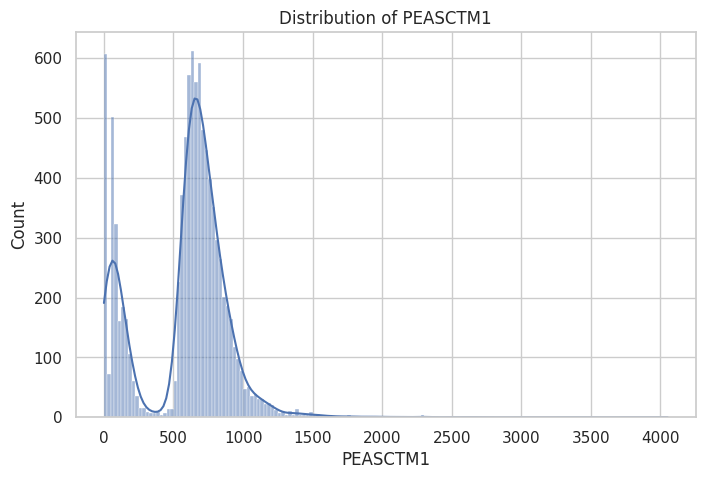

count    9.282000e+03
mean     5.787108e+02
std      3.255306e+02
min      5.397605e-79
25%      5.032500e+02
50%      6.510000e+02
75%      7.670000e+02
max      4.051000e+03
Name: PEASCTM1, dtype: float64




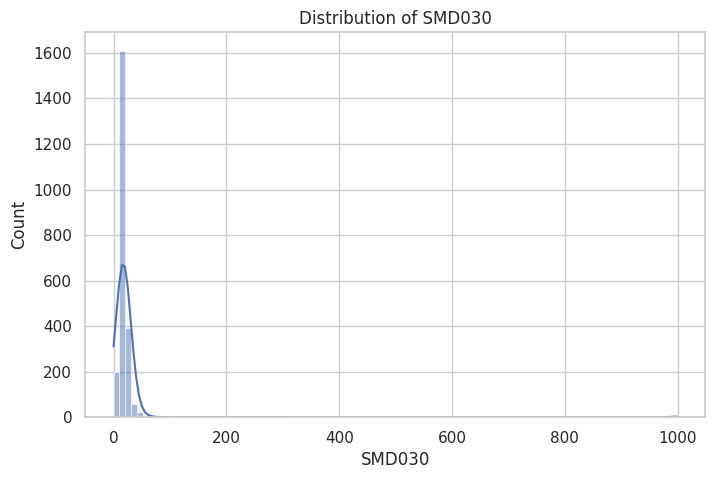

count    2.292000e+03
mean     2.083770e+01
std      5.839776e+01
min      5.397605e-79
25%      1.500000e+01
50%      1.700000e+01
75%      2.000000e+01
max      9.990000e+02
Name: SMD030, dtype: float64




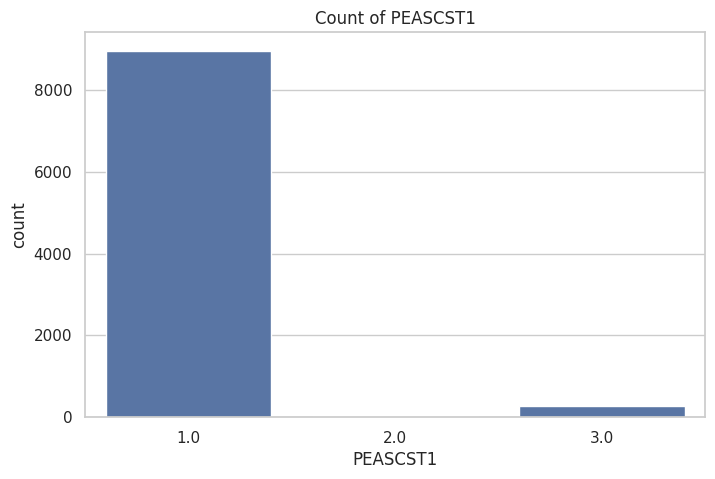

PEASCST1
1.0    8958
3.0     286
2.0      38
Name: count, dtype: int64




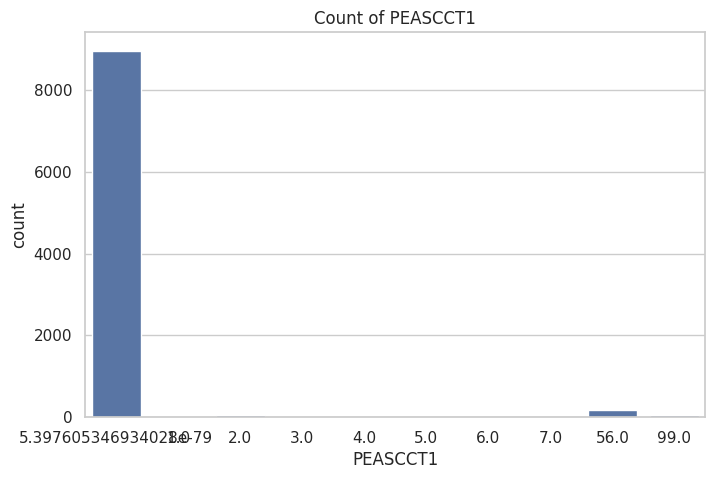

PEASCCT1
5.397605e-79    8960
5.600000e+01     174
9.900000e+01      57
2.000000e+00      52
3.000000e+00      15
7.000000e+00       9
4.000000e+00       7
5.000000e+00       4
1.000000e+00       3
6.000000e+00       1
Name: count, dtype: int64




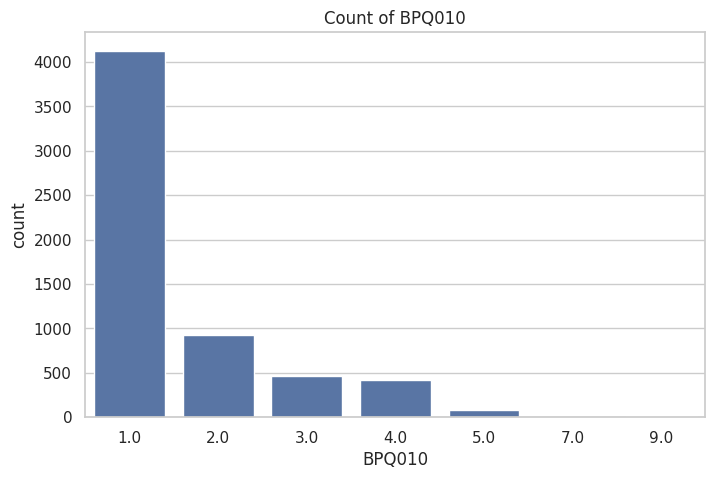

BPQ010
1.0    4129
2.0     922
3.0     460
4.0     424
5.0      86
9.0      16
7.0       3
Name: count, dtype: int64




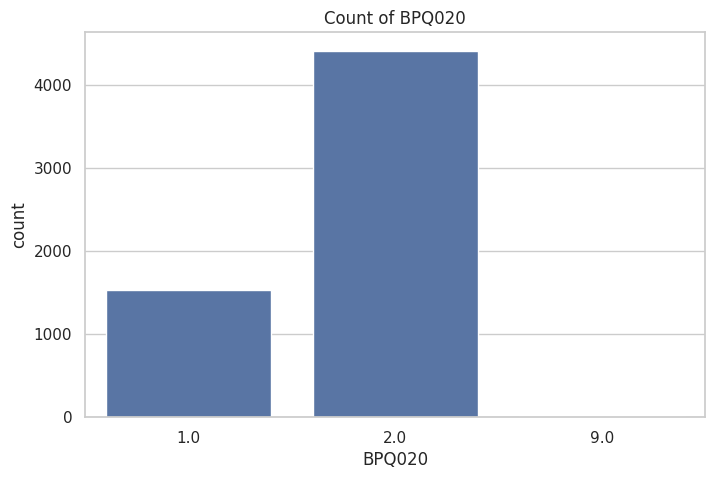

BPQ020
2.0    4408
1.0    1532
9.0      11
Name: count, dtype: int64




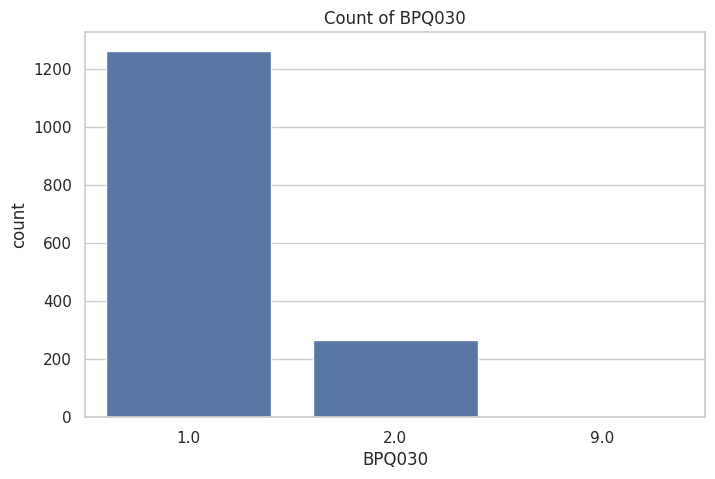

BPQ030
1.0    1263
2.0     266
9.0       3
Name: count, dtype: int64




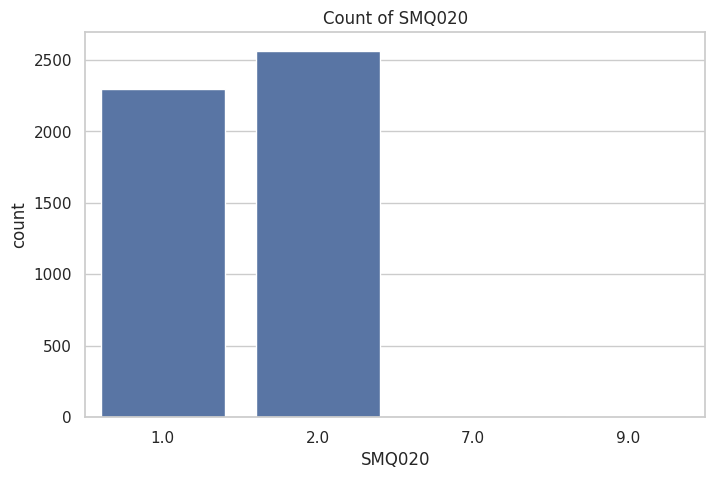

SMQ020
2.0    2566
1.0    2299
9.0       8
7.0       4
Name: count, dtype: int64




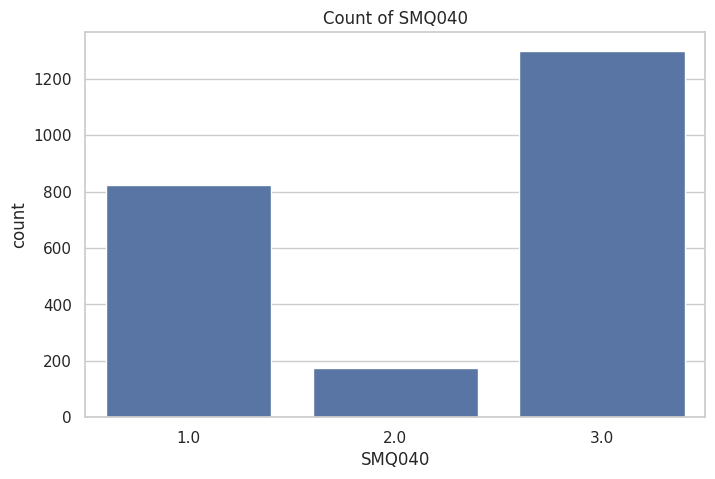

SMQ040
3.0    1300
1.0     823
2.0     176
Name: count, dtype: int64




In [ ]:
# plots histograms for numeric variables and countplots for categorical variables
numeric_cols = ['PEASCTM1', 'SMD030']

for col in numeric_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()
        print(df[col].describe())
        print("\n" + "="*40 + "\n")

categorical_cols = [c for c in eda_cols if c not in numeric_cols]

for col in categorical_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        sns.countplot(x=col, data=df)
        plt.title(f"Count of {col}")
        plt.show()
        print(df[col].value_counts())
        print("\n" + "="*40 + "\n")

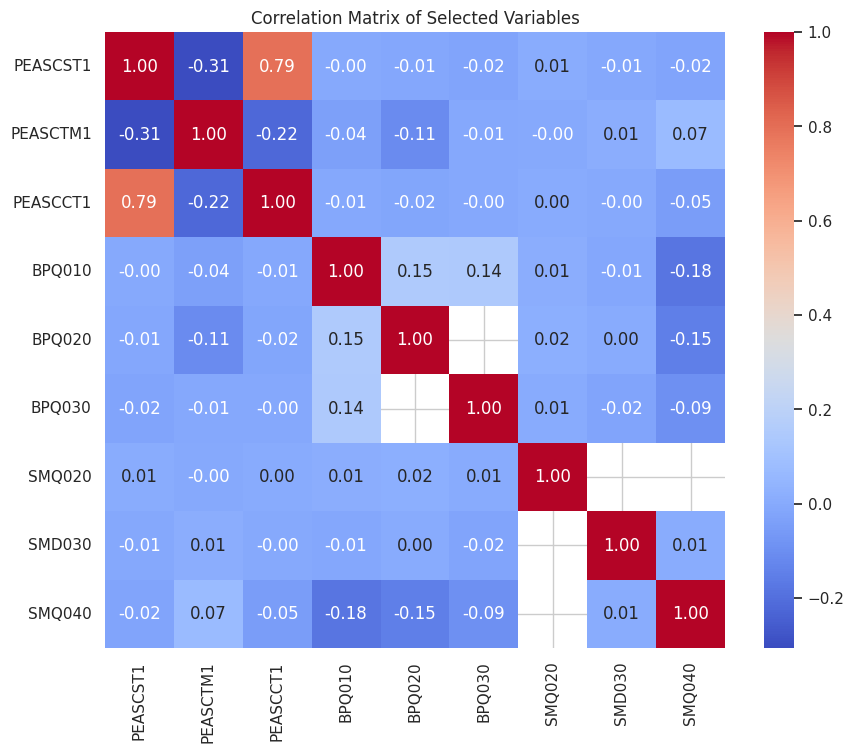

In [ ]:
# creates a correlation heatmap of the selected variables
plt.figure(figsize=(10, 8))
correlation_matrix = df[eda_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Selected Variables")
plt.show()

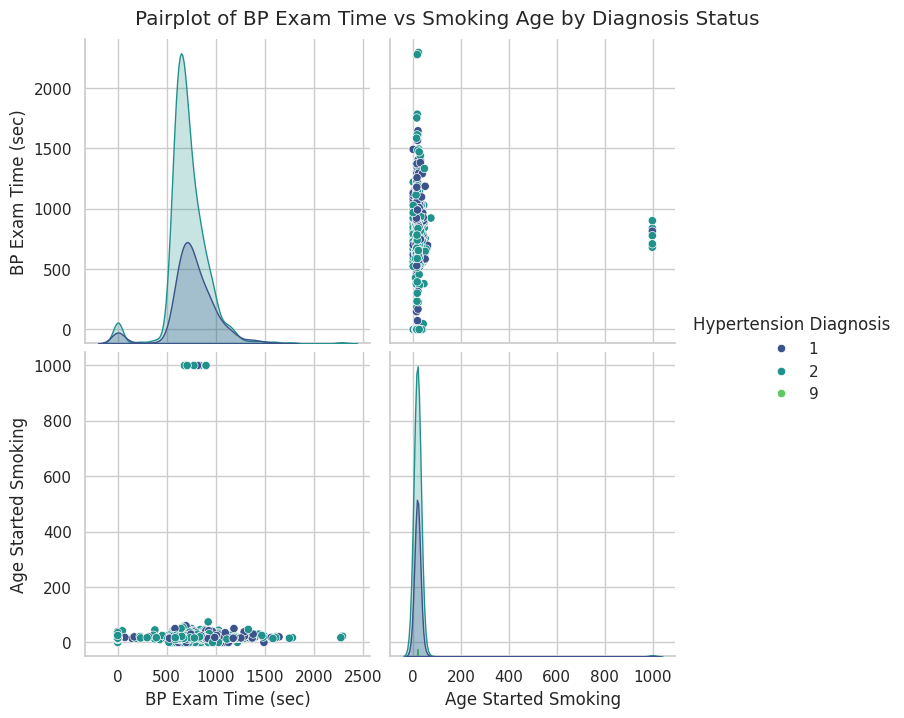

In [ ]:
# creates a pair plot of bp exam time and age started smoking by hypertension diagnosis
pairplot_data = df[['PEASCTM1', 'SMD030', 'BPQ020']].copy()

pairplot_data.columns = ['BP Exam Time (sec)', 'Age Started Smoking', 'Hypertension Diagnosis']

pairplot_data = pairplot_data.dropna()

pairplot_data['Hypertension Diagnosis'] = pairplot_data['Hypertension Diagnosis'].astype(int).astype(str)

sns.pairplot(pairplot_data, hue='Hypertension Diagnosis', palette='viridis', height=3.5)
plt.suptitle("Pairplot of BP Exam Time vs Smoking Age by Diagnosis Status", y=1.02)
plt.show()

Contingency Table: Smoking History vs. Hypertension Diagnosis


Hypertension Diagnosis,No,Yes
Smoked >100 Cigs,,
No,364,1842
Yes,289,1652


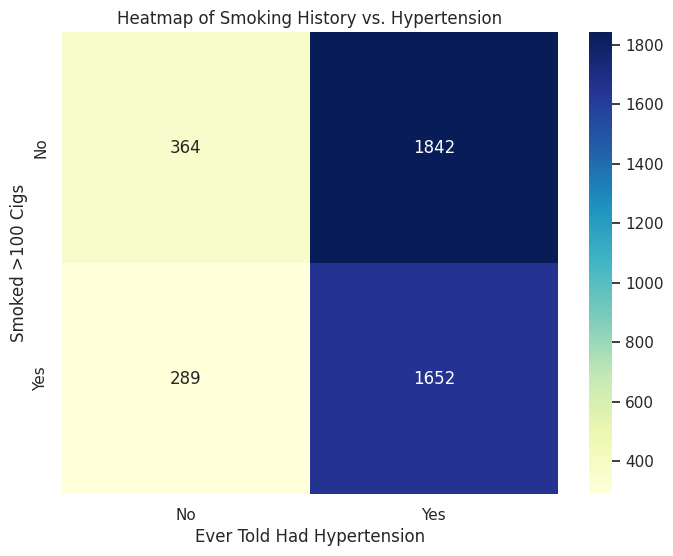

Percentage of Smokers with Hypertension: 85.1%
Percentage of Non-Smokers with Hypertension: 83.5%


In [ ]:
# analyzes the relationship between smoking history and hypertension diagnosis with a contingency table and heatmap
crosstab_df = df[['SMQ020', 'BPQ010']].dropna()

label_map = {1: 'Yes', 2: 'No'}
crosstab_df['Smoked >100 Cigs'] = crosstab_df['SMQ020'].map(label_map)
crosstab_df['Hypertension Diagnosis'] = crosstab_df['BPQ010'].map(label_map)

contingency_table = pd.crosstab(crosstab_df['Smoked >100 Cigs'], crosstab_df['Hypertension Diagnosis'])

print("Contingency Table: Smoking History vs. Hypertension Diagnosis")
display(contingency_table)

plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Heatmap of Smoking History vs. Hypertension")
plt.ylabel("Smoked >100 Cigs")
plt.xlabel("Ever Told Had Hypertension")
plt.show()

total_smokers = contingency_table.loc['Yes'].sum()
smokers_with_hbp = contingency_table.loc['Yes', 'Yes']
print(f"Percentage of Smokers with Hypertension: {(smokers_with_hbp/total_smokers)*100:.1f}%")

total_nonsmokers = contingency_table.loc['No'].sum()
nonsmokers_with_hbp = contingency_table.loc['No', 'Yes']
print(f"Percentage of Non-Smokers with Hypertension: {(nonsmokers_with_hbp/total_nonsmokers)*100:.1f}%")

### Observations

*   **Pairplot**: The pairplot visualizes the relationship between the time taken for the blood pressure exam (`PEASCTM1`) and the age a person started smoking (`SMD030`), colored by whether they have been diagnosed with hypertension (`BPQ010`). We can look for clusters or separation between the groups.
*   **Contingency Table**: The contingency table and heatmap compare smoking status (`SMQ020`) with hypertension diagnosis (`BPQ010`).
    *   Slightly higher percentage of smokers (85.1%) reported having hypertension compared to non-smokers (83.5%).
    *   This suggests a potential weak association, but further statistical testing would be needed to confirm significance.
    *   *Note: The high prevalence of "Yes" for hypertension in this subset might be due to the specific population sampled or how the question was filtered.*